In [3]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

In [8]:
results_dir = Path(os.getcwd()).parent / 'results'

with open(os.path.join(results_dir, 'beam_results.csv'), 'r') as f:
    df = pd.read_csv(f).set_index('beam')

df

,bleu,time_seconds
beam,,
1,19.7,39
2,21.4,23
4,21.9,47
5,21.9,63
6,21.8,68
7,21.8,85
8,21.8,103
10,21.8,148
12,21.7,167


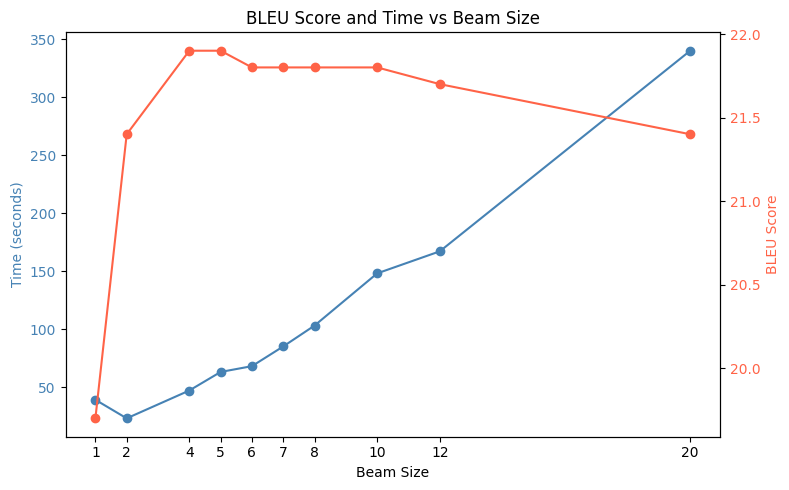

In [17]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color_time = 'steelblue'
color_bleu = 'tomato'

ax1.plot(df.index, df['time_seconds'], marker='o', color=color_time)
ax1.set_xlabel('Beam Size')
ax1.set_ylabel('Time (seconds)', color=color_time)
ax1.tick_params(axis='y', labelcolor=color_time)
ax1.set_xticks(df.index)

ax2 = ax1.twinx()
ax2.plot(df.index, df['bleu'], marker='o', color=color_bleu)
ax2.set_ylabel('BLEU Score', color=color_bleu)
ax2.tick_params(axis='y', labelcolor=color_bleu)

plt.title('BLEU Score and Time vs Beam Size')
plt.tight_layout()
plt.savefig('../results/beam_results_plot.png')
plt.show()


The plotly code was written by Claude.

In [10]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index, y=df['time_seconds'],
    name='Time (s)', mode='lines+markers',
    marker=dict(size=8),
    line=dict(color='steelblue', width=2),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=df.index, y=df['bleu'],
    name='BLEU', mode='lines+markers',
    marker=dict(size=8),
    line=dict(color='tomato', width=2),
    yaxis='y2'
))

fig.update_layout(
    title='BLEU Score and Time vs Beam Size',
    xaxis=dict(title='Beam Size', tickvals=df.index),
    yaxis=dict(
        title=dict(text='Time (seconds)', font=dict(color='steelblue')),
        tickfont=dict(color='steelblue'),
        gridcolor='rgba(70, 130, 180, 0.2)'
    ),
    yaxis2=dict(
        title=dict(text='BLEU Score', font=dict(color='tomato')),
        tickfont=dict(color='tomato'),
        gridcolor='rgba(255, 99, 71, 0.2)',
        overlaying='y', side='right'
    ),
    legend=dict(x=0.5, y=1.1, orientation='h'),
    template='plotly_white',
    hovermode='x unified'
)

fig.write_html(os.path.join(results_dir, 'beam_time_bleu.html'))

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.index, y=df['bleu'],
    mode='markers+text',
    text=df.index.astype(str),
    textposition='top center',
    textfont=dict(color='#333', size=13, family='Arial Black'),
    marker=dict(
        size=df['time_seconds'] / 2.5,
        color=df['bleu'], colorscale='RdYlGn',
        cmin=19.5, cmax=22,
        showscale=True,
        colorbar=dict(title='BLEU', thickness=20),
        line=dict(color='white', width=2.5),
        opacity=0.95
    ),
    hovertemplate='Beam %{x}<br>BLEU %{y}<br>Time %{customdata}s<extra></extra>',
    customdata=df['time_seconds']
))

fig.update_layout(
    title=dict(text='Bubble — BLEU (color) & Time (size) by Beam Size', x=0.5, font=dict(size=20)),
    xaxis=dict(title='Beam Size', tickvals=df.index, showgrid=False),
    yaxis=dict(title='BLEU Score', range=[19, 23], gridcolor='rgba(0,0,0,0.06)'),
    template='plotly_white', plot_bgcolor='#fafafa', showlegend=False
)

fig.write_html(os.path.join(results_dir, 'beam_bleu_time_bubble.html'))